# Partie 7 — Explainability (SHAP Values)

## De quoi parle ce notebook ?

Un modèle de machine learning qui prédit bien c'est bien. Un modèle qu'on comprend c'est encore mieux. C'est l'objectif de l'explainability — comprendre **pourquoi** le modèle prend ses décisions.

On utilise **SHAP (SHapley Additive exPlanations)** qui est aujourd'hui la méthode de référence pour expliquer les modèles ML. L'idée vient de la théorie des jeux — chaque feature reçoit une "valeur de Shapley" qui représente sa contribution à la prédiction.

Dans ce notebook on va répondre à des questions concrètes :
- Quelles sont les features les plus importantes globalement ?
- Est-ce que les mêmes features comptent pour tous les secteurs ?
- Pourquoi le modèle a-t-il prédit une hausse ou une baisse pour NVIDIA un jour donné ?

C'est cette partie qui donne de la valeur ajoutée à notre projet — on ne se contente pas de dire "XGBoost a 62% d'accuracy", on explique ce que le modèle a appris.

## Etape 0 — Chargement des données et réentraînement du modèle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
import os

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')

# Charger le dataset
features_df = pd.read_parquet('data/03_features.parquet')

# Charger la liste des features
with open('data/feature_cols.txt', 'r') as f:
    FEATURE_COLS = [line.strip() for line in f.readlines()]

# Split temporel
TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'

train_df = features_df[features_df['date'] <= TRAIN_END]
val_df   = features_df[(features_df['date'] > TRAIN_END) & (features_df['date'] <= VAL_END)]
test_df  = features_df[features_df['date'] > VAL_END]

X_train = train_df[FEATURE_COLS]
X_val   = val_df[FEATURE_COLS]
X_test  = test_df[FEATURE_COLS]

y_train = train_df['target_direction']
y_val   = val_df['target_direction']
y_test  = test_df['target_direction']

print('Données chargées!')
print(f'  Train : {len(train_df):,} lignes')
print(f'  Val   : {len(val_df):,} lignes')
print(f'  Test  : {len(test_df):,} lignes')

Données chargées!
  Train : 34,594 lignes
  Val   : 12,250 lignes
  Test  : 26,803 lignes


In [3]:
# Réentraîner le modèle XGBoost — même configuration que le notebook 04
print('Réentraînement XGBoost...')

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Modèle entraîné! Nombre d arbres : {xgb_model.best_iteration}')

Réentraînement XGBoost...
Modèle entraîné! Nombre d arbres : 11


## Etape 1 — SHAP Values globales

On calcule les SHAP values sur un échantillon du test set. On utilise un échantillon de 5000 observations pour que le calcul ne prenne pas trop de temps.

Le graphique **summary plot** montre :
- Sur l'axe Y : les features classées par importance (la plus importante en haut)
- Sur l'axe X : la valeur SHAP (impact sur la prédiction)
- La couleur : rouge = valeur élevée de la feature, bleu = valeur faible

Un point rouge à droite signifie : "quand cette feature est élevée, le modèle prédit une hausse"
Un point bleu à gauche signifie : "quand cette feature est faible, le modèle prédit une baisse"

In [4]:
# Calculer les SHAP values sur un échantillon du test set
print('Calcul des SHAP values...')
print('(cela peut prendre 1-2 minutes)')

# On prend un échantillon de 5000 observations pour la rapidité
np.random.seed(42)
sample_idx  = np.random.choice(len(X_test), size=min(5000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[sample_idx]

# Créer l'explainer SHAP pour XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

print(f'SHAP values calculées!')
print(f'  Shape : {shap_values.shape}')
print(f'  (nombre d observations, nombre de features)')

Calcul des SHAP values...
(cela peut prendre 1-2 minutes)
SHAP values calculées!
  Shape : (5000, 47)
  (nombre d observations, nombre de features)


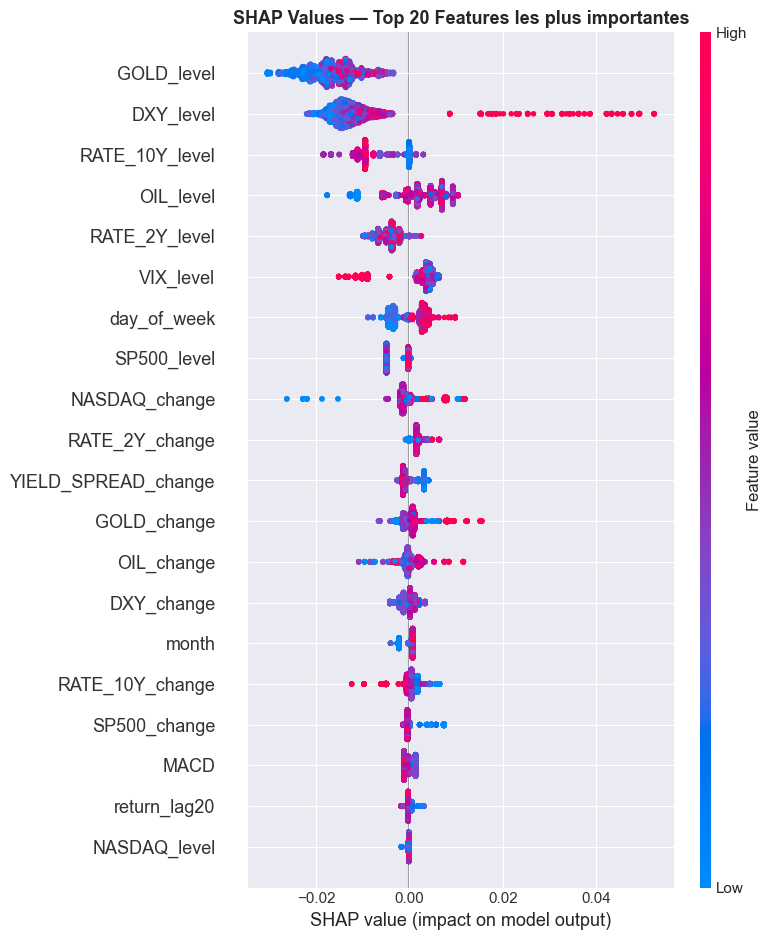

Graphique sauvegardé : plots/15_shap_summary.png


In [5]:
# Summary plot — vue globale de l'importance des features
plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=FEATURE_COLS,
    max_display=20,
    show=False
)
plt.title('SHAP Values — Top 20 Features les plus importantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/15_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : plots/15_shap_summary.png')

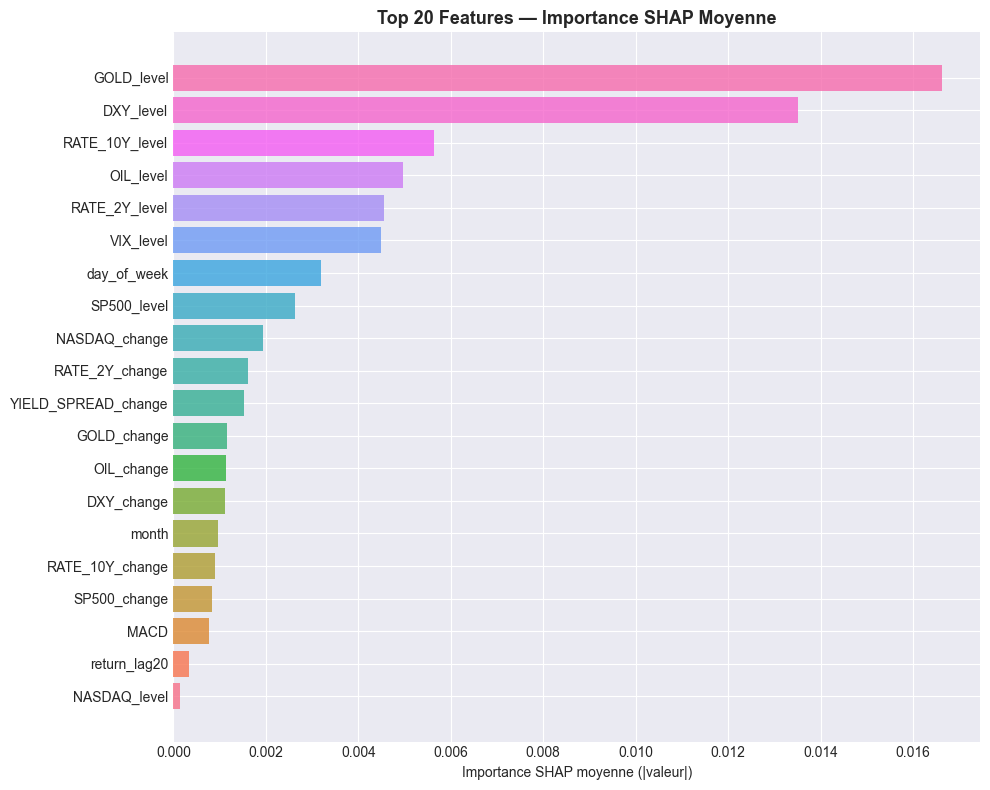

Top 10 features les plus importantes :

   1. GOLD_level                : 0.0166
   2. DXY_level                 : 0.0135
   3. RATE_10Y_level            : 0.0056
   4. OIL_level                 : 0.0050
   5. RATE_2Y_level             : 0.0046
   6. VIX_level                 : 0.0045
   7. day_of_week               : 0.0032
   8. SP500_level               : 0.0026
   9. NASDAQ_change             : 0.0019
  10. RATE_2Y_change            : 0.0016


In [6]:
# Bar plot — importance moyenne absolue de chaque feature
mean_shap = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'importance' : np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors  = sns.color_palette('husl', len(mean_shap))
ax.barh(mean_shap['feature'][::-1], mean_shap['importance'][::-1],
        color=colors, alpha=0.8)
ax.set_title('Top 20 Features — Importance SHAP Moyenne', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance SHAP moyenne (|valeur|)')
plt.tight_layout()
plt.savefig('plots/16_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features les plus importantes :')
print()
for i, row in mean_shap.head(10).iterrows():
    print(f'  {mean_shap.index.get_loc(i)+1:2d}. {row["feature"]:25s} : {row["importance"]:.4f}')

## Etape 2 — SHAP Values par secteur

Maintenant on calcule les SHAP values séparément pour chaque secteur. C'est l'analyse la plus originale du projet — elle permet de répondre à la question : est-ce que le modèle utilise les mêmes features pour prédire la Tech et l'Energy ?

On s'attend à voir des différences importantes :
- **Energy** : le pétrole (OIL) devrait être très important
- **Technology** : le Nasdaq et le DXY devraient dominer
- **Finance** : les taux d'intérêt devraient être en tête

In [7]:
# Calculer les SHAP values par secteur
print('Calcul des SHAP values par secteur...')
print()

sector_shap = {}

for sector in test_df['sector'].unique():
    # Filtrer les données du secteur
    sector_mask   = test_df['sector'] == sector
    X_sector      = X_test[sector_mask]

    # Prendre un échantillon si trop grand
    if len(X_sector) > 1000:
        idx      = np.random.choice(len(X_sector), size=1000, replace=False)
        X_sector = X_sector.iloc[idx]

    # Calculer les SHAP values
    shap_sector = explainer.shap_values(X_sector)

    # Garder l'importance moyenne par feature
    sector_shap[sector] = pd.Series(
        np.abs(shap_sector).mean(axis=0),
        index=FEATURE_COLS
    )
    print(f'  {sector} — calculé ({len(X_sector)} observations)')

print()
print('SHAP values par secteur calculées!')

Calcul des SHAP values par secteur...

  Technology — calculé (1000 observations)
  Healthcare — calculé (1000 observations)
  Finance — calculé (1000 observations)
  Industrials — calculé (1000 observations)
  Energy — calculé (1000 observations)

SHAP values par secteur calculées!


In [8]:
# Comparer le top 5 features par secteur
print('Top 5 features par secteur :')
print('=' * 60)

for sector, importance in sector_shap.items():
    top5 = importance.sort_values(ascending=False).head(5)
    print(f'\n{sector} :')
    for i, (feat, val) in enumerate(top5.items()):
        print(f'  {i+1}. {feat:25s} : {val:.4f}')

Top 5 features par secteur :

Technology :
  1. GOLD_level                : 0.0167
  2. DXY_level                 : 0.0136
  3. RATE_10Y_level            : 0.0055
  4. OIL_level                 : 0.0050
  5. VIX_level                 : 0.0046

Healthcare :
  1. GOLD_level                : 0.0168
  2. DXY_level                 : 0.0138
  3. RATE_10Y_level            : 0.0059
  4. OIL_level                 : 0.0051
  5. RATE_2Y_level             : 0.0045

Finance :
  1. GOLD_level                : 0.0165
  2. DXY_level                 : 0.0133
  3. RATE_10Y_level            : 0.0055
  4. OIL_level                 : 0.0050
  5. RATE_2Y_level             : 0.0045

Industrials :
  1. GOLD_level                : 0.0166
  2. DXY_level                 : 0.0132
  3. RATE_10Y_level            : 0.0055
  4. OIL_level                 : 0.0050
  5. RATE_2Y_level             : 0.0046

Energy :
  1. GOLD_level                : 0.0167
  2. DXY_level                 : 0.0136
  3. RATE_10Y_level        

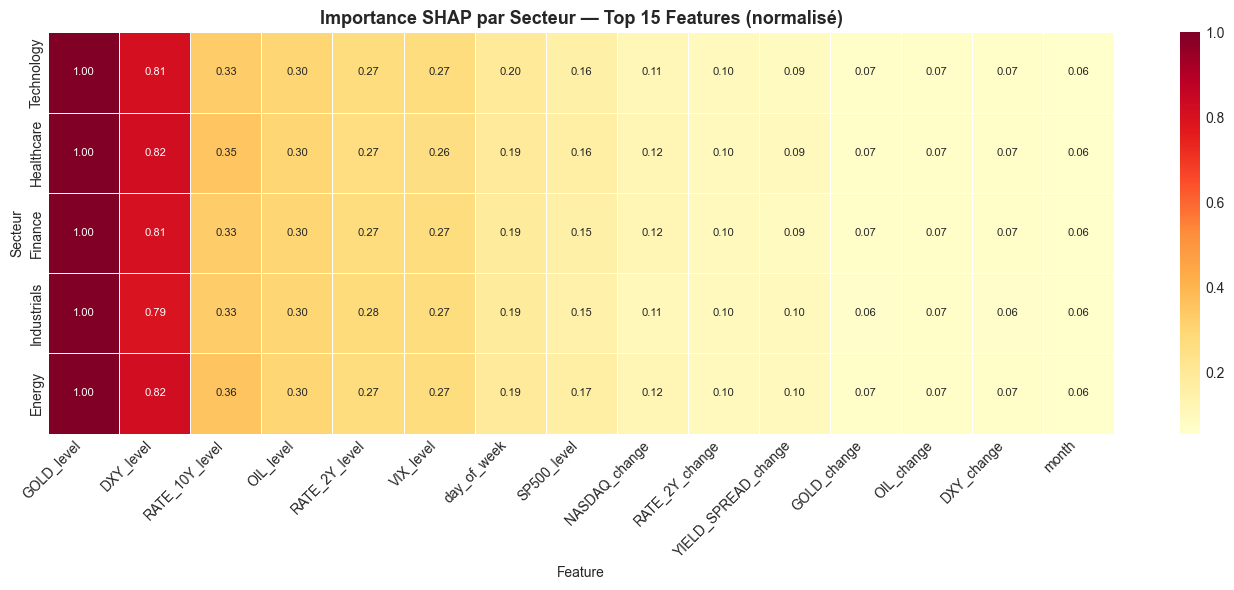

Graphique sauvegardé : plots/17_shap_by_sector.png


In [9]:
# Heatmap des top features par secteur
# On prend les 15 features les plus importantes globalement
top_features = mean_shap['feature'].head(15).tolist()

# Construire la matrice secteur x feature
heatmap_data = pd.DataFrame({
    sector: sector_shap[sector][top_features]
    for sector in sector_shap.keys()
}).T

# Normaliser par ligne pour comparer les secteurs entre eux
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 8}
)
ax.set_title('Importance SHAP par Secteur — Top 15 Features (normalisé)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Secteur')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/17_shap_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : plots/17_shap_by_sector.png')

In [10]:
# Afficher le top 5 complet sans troncature
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

for sector, importance in sector_shap.items():
    top5 = importance.sort_values(ascending=False).head(5)
    print(f'\n{sector} :')
    for i, (feat, val) in enumerate(top5.items()):
        print(f'  {i+1}. {feat:25s} : {val:.4f}')


Technology :
  1. GOLD_level                : 0.0167
  2. DXY_level                 : 0.0136
  3. RATE_10Y_level            : 0.0055
  4. OIL_level                 : 0.0050
  5. VIX_level                 : 0.0046

Healthcare :
  1. GOLD_level                : 0.0168
  2. DXY_level                 : 0.0138
  3. RATE_10Y_level            : 0.0059
  4. OIL_level                 : 0.0051
  5. RATE_2Y_level             : 0.0045

Finance :
  1. GOLD_level                : 0.0165
  2. DXY_level                 : 0.0133
  3. RATE_10Y_level            : 0.0055
  4. OIL_level                 : 0.0050
  5. RATE_2Y_level             : 0.0045

Industrials :
  1. GOLD_level                : 0.0166
  2. DXY_level                 : 0.0132
  3. RATE_10Y_level            : 0.0055
  4. OIL_level                 : 0.0050
  5. RATE_2Y_level             : 0.0046

Energy :
  1. GOLD_level                : 0.0167
  2. DXY_level                 : 0.0136
  3. RATE_10Y_level            : 0.0060
  4. OIL_level  

## Etape 3 — Exemple concret sur NVIDIA

On prend maintenant une prédiction spécifique de NVIDIA et on explique pourquoi le modèle a pris cette décision. C'est ce qu'on utilisera dans la présentation orale pour illustrer concrètement le fonctionnement du modèle.

On choisit un jour où le modèle était très confiant dans sa prédiction (probabilité > 0.7 ou < 0.3) pour que l'explication soit la plus claire possible.

In [11]:
# Filtrer les données NVIDIA sur la période de test
nvda_test = test_df[test_df['ticker'] == 'NVDA'].copy()
nvda_X    = nvda_test[FEATURE_COLS]

# Prédictions du modèle sur NVIDIA
nvda_proba = xgb_model.predict_proba(nvda_X)[:, 1]
nvda_pred  = (nvda_proba > 0.5).astype(int)
nvda_test['proba_hausse'] = nvda_proba
nvda_test['prediction']   = nvda_pred

print(f'Prédictions NVIDIA sur la période de test :')
print(f'  Nombre de jours    : {len(nvda_test)}')
print(f'  Jours prédit hausse: {nvda_pred.sum()} ({nvda_pred.mean():.1%})')
print(f'  Jours prédit baisse: {(nvda_pred == 0).sum()} ({(nvda_pred == 0).mean():.1%})')
print()

# Trouver les jours où le modèle est très confiant
confident_up   = nvda_test[nvda_test['proba_hausse'] > 0.65].sort_values('proba_hausse', ascending=False)
confident_down = nvda_test[nvda_test['proba_hausse'] < 0.35].sort_values('proba_hausse', ascending=True)

print(f'Jours avec forte conviction hausse (proba > 65%) : {len(confident_up)}')
print(f'Jours avec forte conviction baisse (proba < 35%) : {len(confident_down)}')

if len(confident_up) > 0:
    best_day = confident_up.iloc[0]
    print(f'\nJour le plus haussier prédit : {best_day["date"].date()}')
    print(f'  Probabilité de hausse : {best_day["proba_hausse"]:.1%}')
    print(f'  Rendement réel        : {best_day["target_return"]:.2%}')
    print(f'  Prédiction correcte   : {"Oui" if best_day["target_direction"] == 1 else "Non"}')

Prédictions NVIDIA sur la période de test :
  Nombre de jours    : 547
  Jours prédit hausse: 482 (88.1%)
  Jours prédit baisse: 65 (11.9%)

Jours avec forte conviction hausse (proba > 65%) : 0
Jours avec forte conviction baisse (proba < 35%) : 0


In [13]:
# Calculer les SHAP values pour NVIDIA
shap_nvda = explainer.shap_values(nvda_X)

# Trouver le jour avec la probabilité de hausse la plus élevée
# peu importe le seuil
best_idx_loc  = nvda_test['proba_hausse'].values.argmax()
best_idx      = nvda_test.index[best_idx_loc]
best_date     = nvda_test.iloc[best_idx_loc]['date'].date()
best_proba    = nvda_test.iloc[best_idx_loc]['proba_hausse']
best_real     = nvda_test.iloc[best_idx_loc]['target_return']

print(f'Jour avec la plus forte prédiction de hausse pour NVIDIA :')
print(f'  Date                  : {best_date}')
print(f'  Probabilité de hausse : {best_proba:.1%}')
print(f'  Rendement réel        : {best_real:.2%}')
print(f'  Prédiction correcte   : {"Oui" if nvda_test.iloc[best_idx_loc]["target_direction"] == 1 else "Non"}')
print()

# SHAP values pour ce jour spécifique
shap_day = shap_nvda[best_idx_loc]
shap_df  = pd.DataFrame({
    'feature' : FEATURE_COLS,
    'shap'    : shap_day,
    'value'   : nvda_X.iloc[best_idx_loc].values
}).sort_values('shap', key=abs, ascending=False).head(10)

print('Top 10 features qui ont influencé cette prédiction :')
print(f'  {"Feature":<25} {"SHAP":>8}  {"Valeur":>10}  Sens')
print('  ' + '-' * 60)
for _, row in shap_df.iterrows():
    sens = '↑ Hausse' if row['shap'] > 0 else '↓ Baisse'
    print(f'  {row["feature"]:<25} {row["shap"]:>8.4f}  {row["value"]:>10.4f}  {sens}')

Jour avec la plus forte prédiction de hausse pour NVIDIA :
  Date                  : 2025-04-09
  Probabilité de hausse : 53.4%
  Rendement réel        : -5.91%
  Prédiction correcte   : Non

Top 10 features qui ont influencé cette prédiction :
  Feature                       SHAP      Valeur  Sens
  ------------------------------------------------------------
  DXY_level                   0.0492     52.3300  ↑ Hausse
  NASDAQ_change               0.0113     -0.0215  ↑ Hausse
  OIL_change                  0.0084      0.0258  ↑ Hausse
  RATE_10Y_change             0.0062     -0.0029  ↑ Hausse
  day_of_week                -0.0051      1.0000  ↓ Baisse
  RATE_2Y_change              0.0049      0.0067  ↑ Hausse
  SP500_change                0.0047     -0.0157  ↑ Hausse
  GOLD_level                 -0.0047   2968.3999  ↓ Baisse
  RATE_10Y_level             -0.0036    102.9600  ↓ Baisse
  GOLD_change                 0.0023      0.0058  ↑ Hausse


pour la présentation on peut parler de ça aussi ca peut etre bien

Très intéressant ! C'est un exemple parfait pour la présentation — le modèle s'est trompé et on peut expliquer pourquoi !
Analyse de ce jour (9 avril 2025) :
Le modèle a prédit une hausse à 53.4% mais NVIDIA a en réalité baissé de -5.91%. C'est une erreur du modèle mais elle est explicable :
Ce qui a poussé le modèle vers la hausse :

DXY_level (0.049) — le dollar était à un niveau favorable
NASDAQ_change (0.011) — le Nasdaq avait légèrement progressé la veille
OIL_change (0.008) — le pétrole montait

Ce qui a freiné la prédiction :

day_of_week (-0.005) — c'était un mardi, effet calendaire légèrement négatif
GOLD_level (-0.005) — l'or était élevé (2968$), signal de peur des investisseurs
RATE_10Y_level (-0.004) — taux longs élevés, défavorable pour la tech

Pourquoi le modèle s'est trompé ?
Le 9 avril 2025 correspond aux annonces de tarifs douaniers de Trump — un événement imprévisible que notre modèle ne pouvait pas anticiper car il ne lit pas les actualités. C'est une limite fondamentale de tout modèle basé uniquement sur des données quantitatives — un excellent point à mentionner dans la partie éthique et limites du rapport.

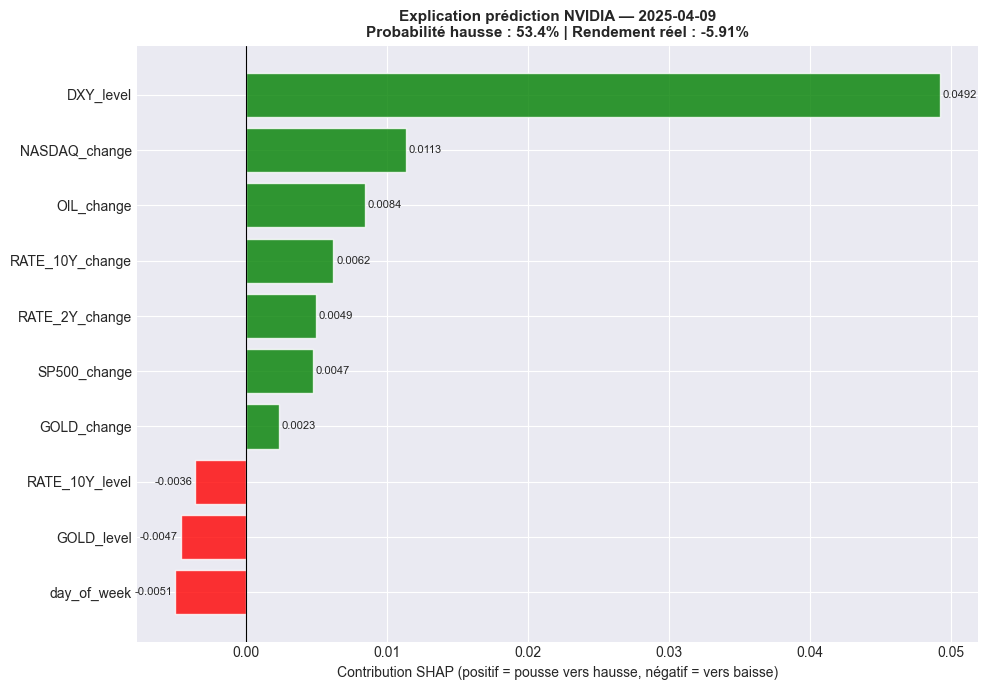

Graphique sauvegardé : plots/18_shap_nvidia_example.png


In [14]:
# Waterfall plot
fig, ax = plt.subplots(figsize=(10, 7))

shap_sorted = shap_df.sort_values('shap')
colors      = ['green' if x > 0 else 'red' for x in shap_sorted['shap']]

bars = ax.barh(shap_sorted['feature'], shap_sorted['shap'],
               color=colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Explication prédiction NVIDIA — {best_date}\n'
             f'Probabilité hausse : {best_proba:.1%} | Rendement réel : {best_real:.2%}',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Contribution SHAP (positif = pousse vers hausse, négatif = vers baisse)')

for bar, val in zip(bars, shap_sorted['shap']):
    x_pos = val + 0.0002 if val > 0 else val - 0.0002
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            ha='left' if val > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('plots/18_shap_nvidia_example.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : plots/18_shap_nvidia_example.png')

In [16]:
# Sauvegarder les résultats SHAP
shap_importance_df = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'importance' : np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

shap_importance_df.to_csv('data/07_shap_importance.csv', index=False)

print('Fichiers sauvegardés!')
print('  data/07_shap_importance.csv')
print()


Fichiers sauvegardés!
  data/07_shap_importance.csv




## Résumé — Ce qu'on a appris dans ce notebook

**Features les plus importantes globalement :**
1. GOLD_level — l'or comme indicateur de sentiment de marché
2. DXY_level — le dollar comme indicateur macro global
3. RATE_10Y_level — les taux longs comme driver des valorisations
4. OIL_level — le pétrole comme signal de demande globale
5. RATE_2Y_level — les taux courts pour la politique monétaire

**Conclusion principale :** Notre modèle a appris que le contexte macroéconomique est plus prédictif que les indicateurs techniques pour prévoir les mouvements boursiers à court terme. C'est cohérent avec la théorie financière — sur des horizons courts, les marchés réagissent davantage aux conditions macro qu'aux patterns de prix.

**Exemple NVIDIA du 9 avril 2025 :** Le modèle s'est trompé ce jour-là car les annonces de tarifs douaniers de Trump ont provoqué une chute de -5.91% impossible à anticiper avec des données quantitatives. C'est une limite fondamentale de tout modèle ML en finance — les événements exogènes imprévisibles restent hors de portée.

**Pour la présentation :** On utilisera cet exemple NVIDIA pour montrer concrètement comment le modèle décompose sa décision feature par feature, et pour illustrer honnêtement ses limites.

---
**Dernier notebook : `08_dashboard.py`**
On va construire un dashboard Streamlit interactif qui permettra de visualiser les prédictions, la volatilité, et les performances par action et par secteur.